# KAGGLE 2: ENSÉÑAME LA PASTA

En esta competición, evaluaremos la eficacia de los modelos utilizando la métrica Area Under Curve (AUC). Esta métrica proporciona una medida de la capacidad del modelo para discriminar entre clases, siendo especialmente relevante en problemas de clasificación binaria.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"test.csv")

In [3]:
df.head()

,ID,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,129460,1.000000,21,0,8.000000,NaN,0,0,0,0,NaN
1,134018,0.009878,38,0,0.229978,10500.0,10,0,1,0,1.0
2,86523,0.276836,70,0,1914.000000,NaN,23,0,1,0,0.0
3,138466,0.045413,75,0,452.000000,NaN,4,0,0,0,0.0
4,143905,0.000000,82,0,0.000000,NaN,5,0,0,0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   ID                                    45000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  45000 non-null  float64
 2   Age                                   45000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  45000 non-null  int64  
 4   DebtRatio                             45000 non-null  float64
 5   MonthlyIncome                         36105 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       45000 non-null  int64  
 7   NumberOfTimes90DaysLate               45000 non-null  int64  
 8   NumberRealEstateLoansOrLines          45000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  45000 non-null  int64  
 10  NumberOfDependents                    43840 non-null  float64
dtypes: float64(4), 

### LIMPIEZA DE DATOS

In [5]:
# cambio los nan con la mediana del train (5400.0)
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(5400.0)

DUDA DE POR QUÉ LA MEDIANA DE TRAIN Y NO DE TEST:  
El test son datos nuevos que no tienes hasta el momento de predecir. Si calculas la mediana del test estás usando información del futuro para limpiar los datos, lo que se llama data leakage.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   ID                                    45000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  45000 non-null  float64
 2   Age                                   45000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  45000 non-null  int64  
 4   DebtRatio                             45000 non-null  float64
 5   MonthlyIncome                         45000 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       45000 non-null  int64  
 7   NumberOfTimes90DaysLate               45000 non-null  int64  
 8   NumberRealEstateLoansOrLines          45000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  45000 non-null  int64  
 10  NumberOfDependents                    43840 non-null  float64
dtypes: float64(4), 

In [7]:
df.describe()

,ID,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,43840.000000
mean,74986.597644,7.612037,52.224267,0.448289,355.247139,6356.634644,8.435978,0.292467,1.016444,0.267511,0.755566
std,43268.443146,336.328241,14.784475,4.494203,2472.160315,7810.865523,5.172986,4.472190,1.126756,4.459097,1.114661
min,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37318.750000,0.029653,41.000000,0.000000,0.175327,3913.000000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75119.500000,0.154037,52.000000,0.000000,0.367499,5400.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112379.250000,0.565636,63.000000,0.000000,0.863632,7375.250000,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,50708.000000,109.000000,98.000000,326442.000000,702500.000000,56.000000,98.000000,32.000000,98.000000,10.000000


* RevolvingUtilizationOfUnsecuredLines

In [9]:
# Mide qué porcentaje del límite de crédito disponible está utilizando una persona
# Es una relación (ratio) que compara el saldo total adeudado en tarjetas de crédito y líneas de crédito personales 
# (excluyendo hipotecas y préstamos para automóviles) con el límite total de crédito disponible.
print(df["RevolvingUtilizationOfUnsecuredLines"].min())
print(df["RevolvingUtilizationOfUnsecuredLines"].max())

# tiene que estar mal, debería estar entre 0 y 1 porque es un porcentaje

0.0
50708.0


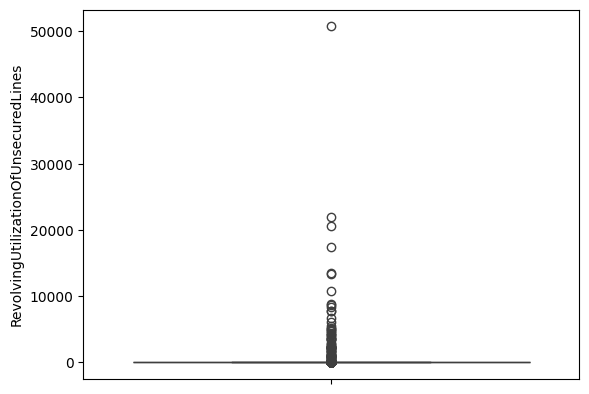

In [10]:
sns.boxplot(df["RevolvingUtilizationOfUnsecuredLines"]);

In [11]:
# leyendo en internet, veo que puede ser algo superior a 1 porque tenga intereses... pero más de 1.3 me parece exagerado

# Ver cuántos valores superan 1.5
mask = df["RevolvingUtilizationOfUnsecuredLines"] > 1.3
print(f"Registros con valor > 1: {mask.sum()} ({mask.mean()*100:.2f}%)")

Registros con valor > 1: 235 (0.52%)


In [12]:
print(df["RevolvingUtilizationOfUnsecuredLines"].quantile([0.25, 0.50, 0.75, 0.90])) # hay un salto grande entre Q2 y Q3

0.25    0.029653
0.50    0.154037
0.75    0.565636
0.90    0.985573
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


In [13]:
# creo una nueva columna que ordene por "grupos" para después hacer ordinalencoder (estilo label encoder pero con orden intrínseco)
df["RevolvingGroup"] = pd.cut(df["RevolvingUtilizationOfUnsecuredLines"],
                               bins=[-1, 0.30, 0.70, 1.0, 50708.0],
                               labels=["bajo", "moderado", "alto", "muy_alto"])

In [14]:
from sklearn.preprocessing import OrdinalEncoder
enc_rev = OrdinalEncoder(categories=[["bajo", "moderado", "alto", "muy_alto"]])
df["RevolvingUtilizationOfUnsecuredLines"] = enc_rev.fit_transform(df[["RevolvingGroup"]])

df.drop(columns=["RevolvingGroup"], inplace=True) # elimino la columna que había creado

* AGE:

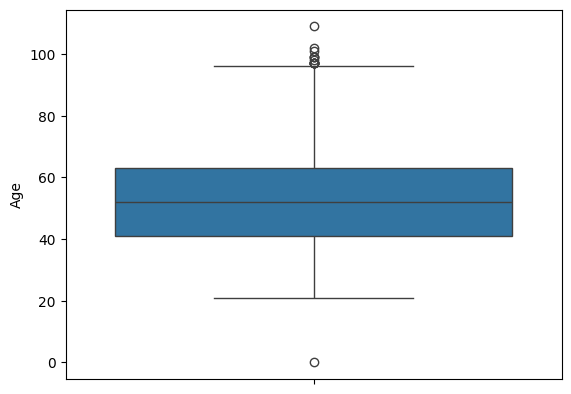

In [15]:
sns.boxplot(df["Age"]);

In [ ]:
# dejo todas

* NumberOfTime30-59DaysPastDueNotWorse

In [88]:
# Número de veces que el cliente se ha retrasado en el pago de 30 a 59 días, pero sin empeorar en los últimos dos años.
# "Not Worse" (Sin empeorar): Significa que, aunque hubo un retraso, el cliente no se retrasó 60 días o más 
# (no cayó en una mora más grave) en ese periodo.

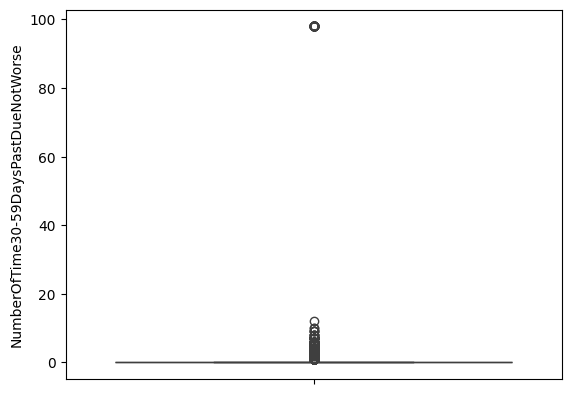

In [89]:
sns.boxplot(df["NumberOfTime30-59DaysPastDueNotWorse"]);

In [90]:
# Ver cuántos valores superan 0
mask = df["NumberOfTime30-59DaysPastDueNotWorse"] > 0
print(f"Registros con valor > 0: {mask.sum()} ({mask.mean()*100:.2f}%)")

Registros con valor > 0: 6005 (16.75%)


In [16]:
# Decido pasarlo a 0 (no se ha retrasado) y 1 (se ha retrasado)
df["NumberOfTime30-59DaysPastDueNotWorse"] = (df["NumberOfTime30-59DaysPastDueNotWorse"] > 0).astype(int)
df["NumberOfTime30-59DaysPastDueNotWorse"].unique()

array([0, 1])

* DebtRatio

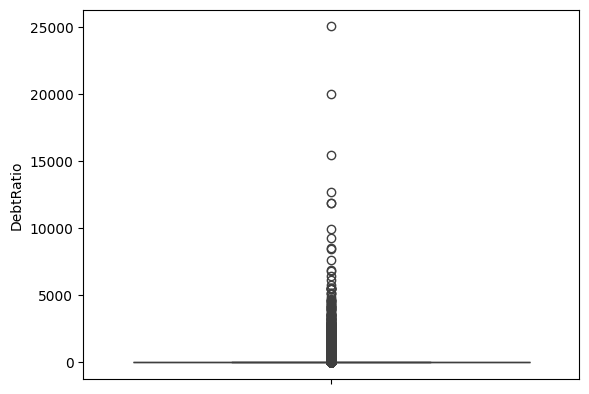

In [92]:
sns.boxplot(df["DebtRatio"]);

In [93]:
# Ver cuántos valores superan 1
mask = df["DebtRatio"] > 2
print(f"Registros con valor > 1: {mask.sum()} ({mask.mean()*100:.2f}%)")

# estos datos son muy heavies... creo que es mejor que los pase con labelencoder tipo "nada", "poco", "medio", "mucho", "extremo"

Registros con valor > 1: 958 (2.67%)


In [17]:
print(df["DebtRatio"].quantile([0.25, 0.50, 0.75, 0.90, 0.95]))

0.25       0.175327
0.50       0.367499
0.75       0.863632
0.90    1243.200000
0.95    2428.000000
Name: DebtRatio, dtype: float64


In [18]:
# Creo una nueva columna haciendo "grupos" por valores (tipo Label Encoder pero con un orden intrínseco)
df["DebtRatioGroup"] = pd.cut(df["DebtRatio"],
                               bins=[-1, 0.1, 0.35, 1.0, float("inf")],
                               labels=["nada", "poco", "medio", "extremo"])

In [19]:
from sklearn.preprocessing import OrdinalEncoder

enc_debt = OrdinalEncoder(categories=[["nada", "poco", "medio", "extremo"]])
df["DebtRatio"] = enc_debt.fit_transform(df[["DebtRatioGroup"]])

df.drop(columns=["DebtRatioGroup"], inplace=True) # elimino la nueva columna que había creado

In [97]:
df["DebtRatio"].unique()

array([1., 3., 2., 0.])

* MonthlyIncome

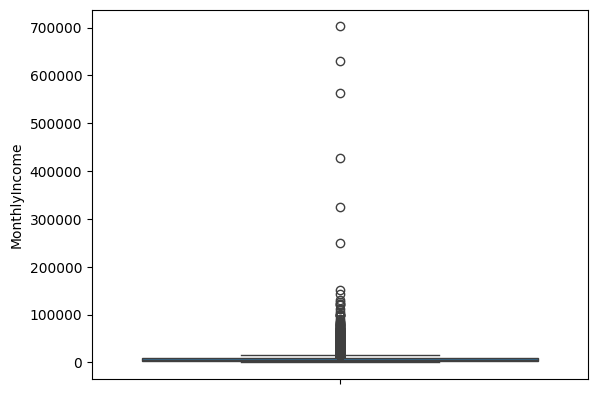

In [98]:
sns.boxplot(df["MonthlyIncome"]);

In [99]:
print(df["MonthlyIncome"].max())
print(df["MonthlyIncome"].min())

702500.0
0.0


In [100]:
print(df["MonthlyIncome"].value_counts(bins=10, sort=False))

(-702.501, 70250.0]     35804
(70250.0, 140500.0]        30
(140500.0, 210750.0]        2
(210750.0, 281000.0]        1
(281000.0, 351250.0]        1
(351250.0, 421500.0]        0
(421500.0, 491750.0]        1
(491750.0, 562000.0]        0
(562000.0, 632250.0]        2
(632250.0, 702500.0]        1
Name: count, dtype: int64


In [101]:
(df["MonthlyIncome"] < 0.1).sum()

np.int64(463)

In [ ]:
(df["MonthlyIncome"] < 100000).sum()
# decido poner todos los que pasen de 150.000 como 150.000 (clampear)

np.int64(35823)

In [20]:
df["MonthlyIncome"] = df["MonthlyIncome"].clip(upper=150000)

In [21]:
print(df["MonthlyIncome"].value_counts(bins=10, sort=False))

(-150.001, 15000.0]     43409
(15000.0, 30000.0]       1362
(30000.0, 45000.0]        121
(45000.0, 60000.0]         46
(60000.0, 75000.0]         28
(75000.0, 90000.0]         13
(90000.0, 105000.0]         5
(105000.0, 120000.0]        3
(120000.0, 135000.0]        4
(135000.0, 150000.0]        9
Name: count, dtype: int64


* NumberOfOpenCreditLinesAndLoans

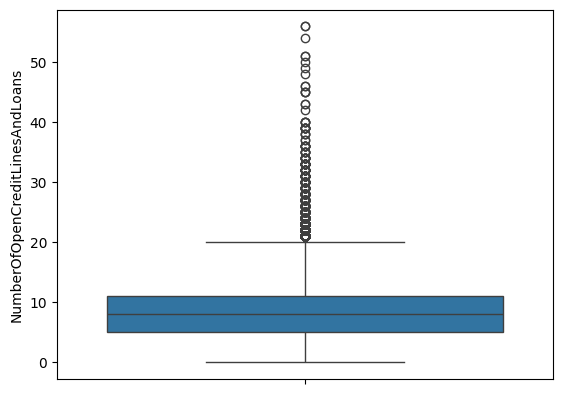

In [105]:
sns.boxplot(df["NumberOfOpenCreditLinesAndLoans"]);

In [106]:
print(df["NumberOfOpenCreditLinesAndLoans"].value_counts(bins=10, sort=False))

(-0.057, 5.6]    10194
(5.6, 11.2]      16772
(11.2, 16.8]      6022
(16.8, 22.4]      2181
(22.4, 28.0]       503
(28.0, 33.6]       101
(33.6, 39.2]        33
(39.2, 44.8]         7
(44.8, 50.4]         8
(50.4, 56.0]         5
Name: count, dtype: int64


In [107]:
# decido dejarla así: hay outliers, pero se pueden manejar

* NumberOfTimes90DaysLate

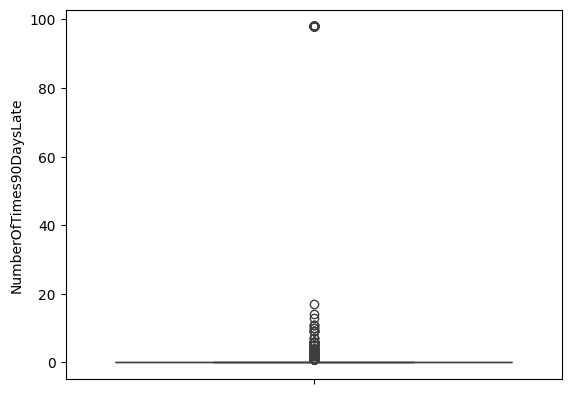

In [108]:
sns.boxplot(df["NumberOfTimes90DaysLate"]);

In [109]:
# Ver cuántos valores superan 0
mask = df["NumberOfTimes90DaysLate"] > 0
print(f"Registros con valor > 0: {mask.sum()} ({mask.mean()*100:.2f}%)")

Registros con valor > 0: 1979 (5.52%)


In [22]:
# Decido pasarlo a 0 (no se ha retrasado) y 1 (se ha retrasado)
df["NumberOfTimes90DaysLate"] = (df["NumberOfTimes90DaysLate"] > 0).astype(int)
df["NumberOfTimes90DaysLate"].unique()

array([0, 1])

* NumberRealEstateLoansOrLines


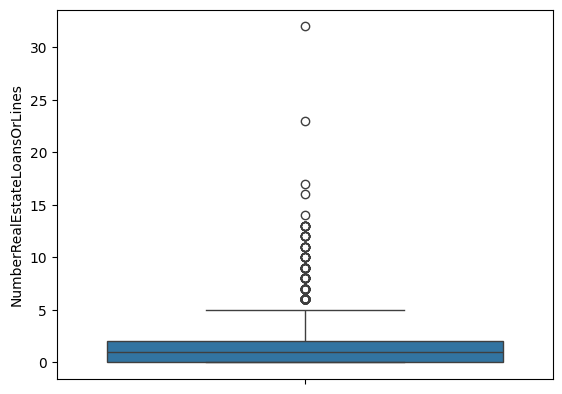

In [111]:
sns.boxplot(df["NumberRealEstateLoansOrLines"]);

In [23]:
print(df["NumberRealEstateLoansOrLines"].value_counts(bins=10, sort=False))

(-0.033, 3.2]    43898
(3.2, 6.4]         957
(6.4, 9.6]         100
(9.6, 12.8]         29
(12.8, 16.0]        11
(16.0, 19.2]         2
(19.2, 22.4]         0
(22.4, 25.6]         2
(25.6, 28.8]         0
(28.8, 32.0]         1
Name: count, dtype: int64


In [24]:
# decido clampear con 25
df["NumberRealEstateLoansOrLines"] = df["NumberRealEstateLoansOrLines"].clip(upper=25)

In [25]:
print(df["NumberRealEstateLoansOrLines"].value_counts(bins=10, sort=False))

(-0.026000000000000002, 2.5]    42042
(2.5, 5.0]                       2708
(5.0, 7.5]                        150
(7.5, 10.0]                        66
(10.0, 12.5]                       18
(12.5, 15.0]                        9
(15.0, 17.5]                        3
(17.5, 20.0]                        1
(20.0, 22.5]                        0
(22.5, 25.0]                        3
Name: count, dtype: int64


* NumberOfTime60-89DaysPastDueNotWorse

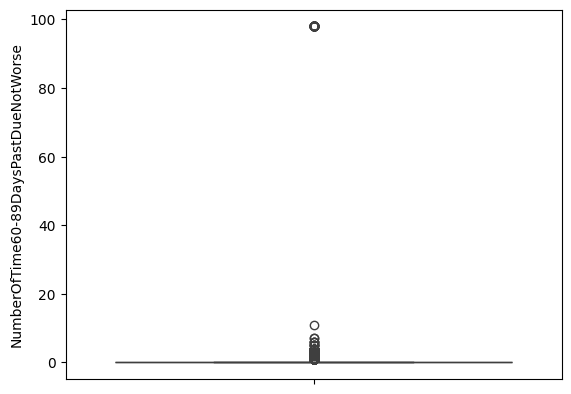

In [115]:
sns.boxplot(df["NumberOfTime60-89DaysPastDueNotWorse"]);

In [116]:
# Ver cuántos valores superan 0
mask = df["NumberOfTime60-89DaysPastDueNotWorse"] > 0
print(f"Registros con valor > 0: {mask.sum()} ({mask.mean()*100:.2f}%)")

Registros con valor > 0: 1860 (5.19%)


In [26]:
# Decido pasarlo a 0 (no se ha retrasado) y 1 (se ha retrasado)
df["NumberOfTime60-89DaysPastDueNotWorse"] = (df["NumberOfTime60-89DaysPastDueNotWorse"] > 0).astype(int)
df["NumberOfTime60-89DaysPastDueNotWorse"].unique()

array([0, 1])

* NumberOfDependents

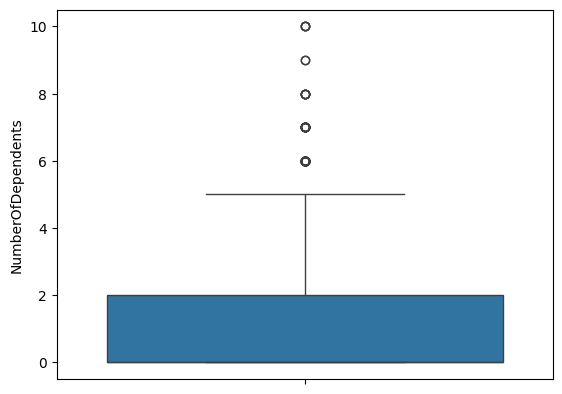

In [118]:
sns.boxplot(df["NumberOfDependents"]);

In [119]:
# Ver cuántos valores superan 5
mask = df["NumberOfDependents"] > 5
print(f"Registros con valor > 5: {mask.sum()} ({mask.mean()*100:.2f}%)")

Registros con valor > 5: 80 (0.22%)


In [29]:
# clampeo con 12
df["NumberOfDependents"] = df["NumberOfDependents"].clip(upper=12)

# NAN con la mediana (0.0)
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0.0)

In [30]:
df["NumberOfDependents"].unique()

array([ 0.,  1.,  2.,  3.,  4.,  5.,  7.,  8.,  6., 10.,  9.])

# DATASET LIMPIO Y GUARDAR EN CSV:

In [31]:
df.head(25)

,ID,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,129460,2.0,21,0,3.0,5400.0,0,0,0,0,0.0
1,134018,0.0,38,0,1.0,10500.0,10,0,1,0,1.0
2,86523,0.0,70,0,3.0,5400.0,23,0,1,0,0.0
3,138466,0.0,75,0,3.0,5400.0,4,0,0,0,0.0
4,143905,0.0,82,0,0.0,5400.0,5,0,0,0,0.0
5,118893,2.0,38,0,1.0,1537.0,1,1,0,1,0.0
6,124587,0.0,68,0,0.0,5400.0,4,0,0,0,0.0
7,136337,1.0,55,0,3.0,3800.0,20,0,2,0,1.0
8,16700,0.0,28,0,1.0,3046.0,8,0,0,0,0.0
9,57857,2.0,56,0,1.0,10523.0,8,0,3,0,0.0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   ID                                    45000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  45000 non-null  float64
 2   Age                                   45000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  45000 non-null  int64  
 4   DebtRatio                             45000 non-null  float64
 5   MonthlyIncome                         45000 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       45000 non-null  int64  
 7   NumberOfTimes90DaysLate               45000 non-null  int64  
 8   NumberRealEstateLoansOrLines          45000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  45000 non-null  int64  
 10  NumberOfDependents                    45000 non-null  float64
dtypes: float64(4), 

In [33]:
df.to_csv("test_limpio.csv", index=False)